# AIN433 Assignment 4- Tiny DETR Implementation

- Barış Çelik
- 2220765033 
- Drive Link: https://drive.google.com/drive/folders/1oJHoQ_suy5tZSlE7oqnacaYxc_eLPlna?usp=sharing

(I used report.pdf for detailed explanations)

1. **Label indexing**: pedestrian=0, no-object=num_classes (DETR convention)
2. **target_classes default**: Unmatched queries → num_classes (no-object)
3. **empty_weight**: Last index (no-object) gets lower weight
4. **Box-safe augmentations**: Scale jitter, crop, flip with proper box handling
5. **Box validity filtering**: Remove invalid boxes after augmentation
6. **Small dataset strategy**: Backbone freezing, LR groups, gradient clipping

In [1]:
import re
import os
import math
import time
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import MultiStepLR, LinearLR, SequentialLR
from PIL import Image
from scipy.optimize import linear_sum_assignment
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.ops as ops

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


Before the main parts of code, arrange the dataset.


In [ ]:
# arrange Dataset distribution
import os
import shutil

path = "PennFudanPed"
image_path = os.path.join(path, "PNGImages")
annotiation_path = os.path.join(path, "Annotation")

# make a new folder inside PennFudanPed -> Pedestrian and put images and annotations there
new_path = os.path.join(path, "Pedestrian")
if not os.path.exists(new_path):
    os.makedirs(new_path)
    
for file_name in os.listdir(image_path):
    # move image
    shutil.move(os.path.join(image_path, file_name), os.path.join(new_path, file_name))
    
    # move annotation
    annotiation_file_name = file_name.split(".")[0] + ".txt"
    shutil.move(os.path.join(annotiation_path, annotiation_file_name), os.path.join(new_path, annotiation_file_name))

Downloaded Dataset is organized as described in pdf. PennFudanPed -> Pedestrian (...)

## 1. Robust Annotation Parsing

In [2]:
def parse_annotation(anno_path, width, height):
    """
    Parse PennFudan annotation file.
    Returns: list of [cx, cy, w, h] normalized to [0, 1]
    """
    with open(anno_path, 'r') as f:
        text = f.read()
    
    # More robust pattern - handles various spacing
    bbox_pattern = r'Bounding box for object \d+.*?:\s*\((\d+),\s*(\d+)\)\s*-\s*\((\d+),\s*(\d+)\)'
    matches = re.findall(bbox_pattern, text)
    
    bboxes = []
    for match in matches:
        xmin, ymin, xmax, ymax = map(int, match)
        
        # Clamp to image bounds
        xmin = max(0, min(xmin, width - 1))
        xmax = max(0, min(xmax, width))
        ymin = max(0, min(ymin, height - 1))
        ymax = max(0, min(ymax, height))
        
        # Ensure valid box
        if xmax <= xmin or ymax <= ymin:
            continue
        
        # Convert to normalized cxcywh
        cx = (xmin + xmax) / 2.0 / width
        cy = (ymin + ymax) / 2.0 / height
        w = (xmax - xmin) / width
        h = (ymax - ymin) / height
        
        # Filter tiny boxes (likely annotation errors)
        if w > 0.01 and h > 0.01:
            bboxes.append([cx, cy, w, h])
    
    return bboxes

## 2. Box-Safe Augmentation Utilities

In [3]:
def cxcywh_to_xyxy(boxes):
    """Convert [cx, cy, w, h] to [x1, y1, x2, y2] - works with numpy or tensor"""
    if len(boxes) == 0:
        return boxes
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    if isinstance(boxes, torch.Tensor):
        return torch.stack([x1, y1, x2, y2], dim=1)
    return np.stack([x1, y1, x2, y2], axis=1)


def xyxy_to_cxcywh(boxes):
    """Convert [x1, y1, x2, y2] to [cx, cy, w, h]"""
    if len(boxes) == 0:
        return boxes
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    if isinstance(boxes, torch.Tensor):
        return torch.stack([cx, cy, w, h], dim=1)
    return np.stack([cx, cy, w, h], axis=1)


def filter_valid_boxes(boxes, min_area=0.0001, min_side=0.01):
    """
    Filter out invalid boxes after augmentation.
    boxes: [N, 4] in cxcywh format, normalized [0, 1]
    Returns: valid boxes and mask
    """
    if len(boxes) == 0:
        return boxes, np.array([], dtype=bool)
    
    # Check bounds
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    
    # Valid if: center in [0,1], positive size, minimum area
    valid = (
        (cx >= 0) & (cx <= 1) &
        (cy >= 0) & (cy <= 1) &
        (w > min_side) & (h > min_side) &
        (w * h > min_area)
    )
    
    return boxes[valid], valid


def clip_boxes_to_image(boxes):
    """
    Clip boxes to [0, 1] range.
    boxes: [N, 4] in cxcywh normalized format
    """
    if len(boxes) == 0:
        return boxes
    
    # Convert to xyxy for clipping
    boxes_xyxy = cxcywh_to_xyxy(boxes)
    
    # Clip
    if isinstance(boxes_xyxy, torch.Tensor):
        boxes_xyxy = boxes_xyxy.clamp(0, 1)
    else:
        boxes_xyxy = np.clip(boxes_xyxy, 0, 1)
    
    # Convert back
    return xyxy_to_cxcywh(boxes_xyxy)

## 3. Dataset with Box-Safe Augmentations

In [4]:
class PennFudanDataset(Dataset):
    """
    PennFudanPed Dataset with box-safe augmentations.
    
    Label convention (DETR standard):
    - pedestrian = 0
    - no-object = num_classes (handled in loss, not in dataset)
    """
    
    def __init__(self, root, split_file, train=False, img_size=512):
        self.root = root
        self.train = train
        self.img_size = img_size
        self.img_path = os.path.join(root, 'Pedestrian')
        
        with open(split_file, 'r') as f:
            self.img_files = [line.strip() for line in f if line.strip()]
        
        # ImageNet normalization
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        img_file = self.img_files[idx]
        img_path = os.path.join(self.img_path, img_file)
        anno_path = os.path.join(self.img_path, img_file.replace('.png', '.txt'))
        
        # Load image
        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size
        
        # Parse annotations (normalized cxcywh)
        boxes = parse_annotation(anno_path, orig_w, orig_h)
        boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32)
        
        if self.train:
            img, boxes = self._apply_augmentations(img, boxes)
        else:
            # Just resize for val/test
            img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        
        # Convert to tensor
        img = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        
        # Normalize
        img = (img - self.mean) / self.std
        
        # Convert boxes to tensor
        boxes = torch.from_numpy(boxes).float() if len(boxes) > 0 else torch.zeros((0, 4))
        
        # Labels: pedestrian = 0 (DETR convention)
        labels = torch.zeros(len(boxes), dtype=torch.int64)
        
        target = {'boxes': boxes, 'labels': labels}
        return img, target
    
    def _apply_augmentations(self, img, boxes):
        """
        Apply box-safe augmentations with proper clamping and filtering.
        """
        orig_w, orig_h = img.size
        
        # 1. Scale Jitter
        scale = random.uniform(0.5, 1.5)
        new_w = int(orig_w * scale)
        new_h = int(orig_h * scale)
        img = img.resize((new_w, new_h), Image.BILINEAR)
        # Boxes stay normalized - scale doesn't change normalized coords
        
        # 2. Random Crop or Pad (with proper box handling)
        img, boxes = self._random_crop_or_pad(img, boxes, self.img_size)
        
        # 3. Horizontal Flip
        if random.random() > 0.5:
            img = TF.hflip(img)
            if len(boxes) > 0:
                boxes[:, 0] = 1.0 - boxes[:, 0]
        
        # 4. Color Jitter (image only - no box changes)
        if random.random() > 0.5:
            img = TF.adjust_brightness(img, random.uniform(0.7, 1.3))
        if random.random() > 0.5:
            img = TF.adjust_contrast(img, random.uniform(0.7, 1.3))
        if random.random() > 0.5:
            img = TF.adjust_saturation(img, random.uniform(0.7, 1.3))
        if random.random() > 0.3:
            img = TF.adjust_hue(img, random.uniform(-0.1, 0.1))
        
        # 5. FINAL: Clamp boxes to [0, 1] and filter invalid
        if len(boxes) > 0:
            # Clamp centers and sizes
            boxes[:, 0] = np.clip(boxes[:, 0], 0, 1)  # cx
            boxes[:, 1] = np.clip(boxes[:, 1], 0, 1)  # cy
            boxes[:, 2] = np.clip(boxes[:, 2], 0, 1)  # w
            boxes[:, 3] = np.clip(boxes[:, 3], 0, 1)  # h
            
            # Ensure box edges don't exceed [0, 1]
            # x1 = cx - w/2 >= 0  =>  w <= 2*cx
            # x2 = cx + w/2 <= 1  =>  w <= 2*(1-cx)
            max_w = np.minimum(2 * boxes[:, 0], 2 * (1 - boxes[:, 0]))
            max_h = np.minimum(2 * boxes[:, 1], 2 * (1 - boxes[:, 1]))
            boxes[:, 2] = np.minimum(boxes[:, 2], max_w)
            boxes[:, 3] = np.minimum(boxes[:, 3], max_h)
            
            # Filter boxes with tiny area
            valid = (boxes[:, 2] > 0.01) & (boxes[:, 3] > 0.01)
            boxes = boxes[valid]
        
        return img, boxes

    
    def _random_crop_or_pad(self, img, boxes, target_size):
        """
        Random crop if image larger than target, or pad if smaller.
        Properly handles boxes: clip to crop region, filter invalid, convert back.
        """
        w, h = img.size
        
        if w >= target_size and h >= target_size:
            # Random crop
            left = random.randint(0, w - target_size)
            top = random.randint(0, h - target_size)
            right = left + target_size
            bottom = top + target_size
            
            img = TF.crop(img, top, left, target_size, target_size)
            
            if len(boxes) > 0:
                # 1. Convert normalized cxcywh to pixel xyxy
                boxes_pixel = boxes.copy()
                cx = boxes_pixel[:, 0] * w
                cy = boxes_pixel[:, 1] * h
                bw = boxes_pixel[:, 2] * w
                bh = boxes_pixel[:, 3] * h
                
                x1 = cx - bw / 2
                y1 = cy - bh / 2
                x2 = cx + bw / 2
                y2 = cy + bh / 2
                
                # 2. Clip boxes to crop region
                x1 = np.clip(x1, left, right)
                y1 = np.clip(y1, top, bottom)
                x2 = np.clip(x2, left, right)
                y2 = np.clip(y2, top, bottom)
                
                # 3. Shift to crop coordinates (0 to target_size)
                x1 = x1 - left
                y1 = y1 - top
                x2 = x2 - left
                y2 = y2 - top
                
                # 4. Filter invalid boxes (zero or negative area)
                valid = (x2 > x1 + 1) & (y2 > y1 + 1)  # at least 1 pixel
                
                if valid.sum() > 0:
                    x1, y1, x2, y2 = x1[valid], y1[valid], x2[valid], y2[valid]
                    
                    # 5. Convert back to normalized cxcywh
                    cx = (x1 + x2) / 2 / target_size
                    cy = (y1 + y2) / 2 / target_size
                    bw = (x2 - x1) / target_size
                    bh = (y2 - y1) / target_size
                    
                    boxes = np.stack([cx, cy, bw, bh], axis=1).astype(np.float32)
                else:
                    boxes = np.zeros((0, 4), dtype=np.float32)
        else:
            # Pad to target size (center the image)
            pad_w = max(0, target_size - w)
            pad_h = max(0, target_size - h)
            pad_left = pad_w // 2
            pad_top = pad_h // 2
            
            # Pad image with gray
            new_img = Image.new('RGB', (target_size, target_size), (128, 128, 128))
            new_img.paste(img, (pad_left, pad_top))
            img = new_img
            
            if len(boxes) > 0:
                # Convert normalized coords to new padded image coords
                # Original box in pixels: cx*w, cy*h, w*bw, h*bh
                # After padding: shift by pad_left, pad_top, then normalize to target_size
                cx = (boxes[:, 0] * w + pad_left) / target_size
                cy = (boxes[:, 1] * h + pad_top) / target_size
                bw = boxes[:, 2] * w / target_size
                bh = boxes[:, 3] * h / target_size
                
                boxes = np.stack([cx, cy, bw, bh], axis=1).astype(np.float32)
        
        return img, boxes


def collate_fn(batch):
    """Custom collate for variable number of boxes per image."""
    return tuple(zip(*batch))

## 4. Fixed 2D Positional Encoding

In [5]:
class PositionalEncoding2D(nn.Module):
    """
    2D sinusoidal positional encoding (DETR style).
    """
    def __init__(self, hidden_dim, temperature=10000):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.temperature = temperature
        self._cache = {}
    
    def forward(self, H, W, device):
        key = (H, W, str(device))
        if key in self._cache:
            return self._cache[key]
        
        # Create coordinate grids
        y_pos = torch.arange(H, dtype=torch.float32, device=device)
        x_pos = torch.arange(W, dtype=torch.float32, device=device)
        
        # Normalize to [0, 1]
        y_pos = y_pos / (H + 1e-6)
        x_pos = x_pos / (W + 1e-6)
        
        # Create 2D meshgrid
        y_grid, x_grid = torch.meshgrid(y_pos, x_pos, indexing='ij')
        
        # Compute positional encoding
        num_pos_feats = self.hidden_dim // 2
        dim_t = torch.arange(num_pos_feats, dtype=torch.float32, device=device)
        dim_t = self.temperature ** (2 * torch.div(dim_t, 2, rounding_mode='floor') / num_pos_feats)
        
        # [H, W, num_pos_feats]
        pos_x = x_grid[:, :, None] / dim_t
        pos_y = y_grid[:, :, None] / dim_t
        
        # Apply sin/cos
        pos_x = torch.stack([pos_x[:, :, 0::2].sin(), pos_x[:, :, 1::2].cos()], dim=3)
        pos_y = torch.stack([pos_y[:, :, 0::2].sin(), pos_y[:, :, 1::2].cos()], dim=3)
        
        pos_x = pos_x.flatten(2)  # [H, W, num_pos_feats]
        pos_y = pos_y.flatten(2)  # [H, W, num_pos_feats]
        
        # Concatenate
        pos = torch.cat([pos_y, pos_x], dim=2)  # [H, W, hidden_dim]
        pos = pos.flatten(0, 1)  # [H*W, hidden_dim]
        
        self._cache[key] = pos
        return pos

## 5. TinyDETR Model

In [ ]:
class TinyDETR(nn.Module):
    """
    Tiny DETR for small dataset.
    
    Output:
    - pred_logits: [B, num_queries, num_classes + 1]
      - Classes 0..num_classes-1 are object classes (pedestrian=0)
      - Class num_classes is no-object
    - pred_boxes: [B, num_queries, 4] in normalized cxcywh
    """
    
    def __init__(self, num_classes=1, num_queries=15, hidden_dim=256, nheads=8,
                 num_encoder_layers=3, num_decoder_layers=3, backbone_name='resnet18'):
        super().__init__()
        self.num_classes = num_classes
        self.num_queries = num_queries
        self.hidden_dim = hidden_dim
        
        # Backbone
        if backbone_name == 'resnet18':
            backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            self.backbone = nn.Sequential(
                backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
                backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
            )
            backbone_out = 512
        elif backbone_name == 'mobilenet_v2':
            backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
            self.backbone = backbone.features
            backbone_out = 1280
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")
        
        # Initially freeze all backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Input projection
        self.input_proj = nn.Conv2d(backbone_out, hidden_dim, kernel_size=1)
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding2D(hidden_dim)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nheads, dim_feedforward=hidden_dim * 4,
            dropout=0.1, activation='relu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        
        # Transformer decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim, nhead=nheads, dim_feedforward=hidden_dim * 4,
            dropout=0.1, activation='relu', batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        
        # Object queries
        self.query_embed = nn.Embedding(num_queries, hidden_dim)
        nn.init.normal_(self.query_embed.weight, std=0.01)
        
        # Prediction heads
        # Classification: num_classes + 1 (last is no-object)
        self.class_head = nn.Linear(hidden_dim, num_classes + 1)
        
        # Bounding box head
        self.bbox_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4)
        )
        
        self._init_heads()
    
    def _init_heads(self):
        """Initialize prediction heads with proper bias."""
        # Class head
        nn.init.xavier_uniform_(self.class_head.weight)
        nn.init.zeros_(self.class_head.bias)
        # Bias towards no-object (last class) initially
        # This helps training stability
        prior_prob = 0.01
        bias_value = -math.log((1 - prior_prob) / prior_prob)
        # Set object class biases to negative (predict no-object more)
        # self.class_head.bias.data[:-1] = bias_value   object classes
        self.class_head.bias.data[-1] = bias_value  # no-object: +4.59
        # Object classes stay at 0 (or slightly negative)
        
        # Bbox head
        for m in self.bbox_head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def print_backbone_structure(self):
        """Print backbone layer structure for debugging."""
        print(f"\nBackbone structure ({len(list(self.backbone.children()))} layers):")
        total_params = 0
        for idx, layer in enumerate(self.backbone.children()):
            params = sum(p.numel() for p in layer.parameters())
            trainable = sum(p.numel() for p in layer.parameters() if p.requires_grad)
            total_params += params
            status = "✓" if trainable > 0 else "✗"
            print(f"  [{idx}] {status} {params:>10,} params ({type(layer).__name__})")
        print(f"  Total backbone params: {total_params:,}")
    
    def unfreeze_backbone_by_params(self, target_params):
        """Unfreeze layers from end until reaching target param count."""
        backbone_layers = list(self.backbone.children())
        
        unfrozen_total = 0
        
        # Go from end to start
        for idx in range(len(backbone_layers) - 1, -1, -1):
            layer = backbone_layers[idx]
            layer_params = sum(p.numel() for p in layer.parameters())
            
            if layer_params == 0:
                continue
            
            # FIXED: Changed <= to allow partial unfreezing
            # If this layer fits in remaining budget, unfreeze it
            if unfrozen_total + layer_params <= target_params:
                for param in layer.parameters():
                    param.requires_grad = True
                unfrozen_total += layer_params
                print(f"  Unfroze layer [{idx}]: +{layer_params:,} params")
            
        
        # If nothing was unfrozen but we have a target, unfreeze the smallest layer that fits
        if unfrozen_total == 0 and target_params > 0:
            # Find smallest layer
            layer_sizes = []
            for idx, layer in enumerate(backbone_layers):
                params = sum(p.numel() for p in layer.parameters())
                if params > 0:
                    layer_sizes.append((idx, params))
            
            # Sort by size and unfreeze smallest
            layer_sizes.sort(key=lambda x: x[1])
            for idx, params in layer_sizes:
                if params <= target_params * 2:  # Allow up to 2x target for flexibility
                    layer = backbone_layers[idx]
                    for param in layer.parameters():
                        param.requires_grad = True
                    unfrozen_total = params
                    print(f"  Unfroze smallest suitable layer [{idx}]: +{params:,} params")
                    break
        
        print(f"  Total unfrozen from backbone: {unfrozen_total:,} params")
        return unfrozen_total    
    
    def unfreeze_backbone(self, num_layers=None, target_params=None):
        """
        Flexible backbone unfreezing.
        
        Args:
            num_layers: Unfreeze last N layers (old behavior)
            target_params: Unfreeze until reaching this param count (new)
        """
        if target_params is not None:
            return self.unfreeze_backbone_by_params(target_params)
        
        elif num_layers is not None:
            layers = list(self.backbone.children())
            unfrozen = 0
            for layer in layers[-num_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True
                    unfrozen += param.numel()
            print(f"  Unfroze last {num_layers} layers: {unfrozen:,} params")
            return unfrozen
        
        else:
            # Unfreeze all
            unfrozen = 0
            for param in self.backbone.parameters():
                param.requires_grad = True
                unfrozen += param.numel()
            print(f"  Unfroze all backbone: {unfrozen:,} params")
            return unfrozen

    
    def forward(self, images):
        if isinstance(images, (list, tuple)):
            images = torch.stack(images)
        
        B = images.shape[0]
        device = images.device
        
        # Backbone features
        features = self.backbone(images)
        features = self.input_proj(features)  # [B, hidden_dim, H, W]
        
        _, _, H, W = features.shape
        
        # Flatten spatial dims
        features = features.flatten(2).permute(0, 2, 1)  # [B, H*W, hidden_dim]
        
        # Positional encoding
        pos = self.pos_encoder(H, W, device)  # [H*W, hidden_dim]
        pos = pos.unsqueeze(0).expand(B, -1, -1)  # [B, H*W, hidden_dim]
        
        # Encoder
        memory = self.encoder(features + pos)
        
        # Decoder
        queries = self.query_embed.weight.unsqueeze(0).expand(B, -1, -1)
        hs = self.decoder(queries, memory + pos)
        
        # Predictions
        outputs_class = self.class_head(hs)  # [B, Q, num_classes+1]
        outputs_bbox = self.bbox_head(hs).sigmoid()  # [B, Q, 4]
        
        return {'pred_logits': outputs_class, 'pred_boxes': outputs_bbox}
    
    def train(self, mode=True):
        """
        Override train mode to keep Backbone BatchNorm in eval mode.
        This is CRITICAL for small batch sizes.
        """
        super().train(mode)
        
        if mode and hasattr(self, 'backbone'):
            # Freeze BatchNorm layers in backbone (keep eval mode)
            for module in self.backbone.modules():
                if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
                    module.eval()
                    # Freeze BN parameters too (no gradient updates)
                    module.weight.requires_grad = False
                    module.bias.requires_grad = False

## 6. Loss Function (SetCriterion)

In [7]:
def box_cxcywh_to_xyxy(boxes):
    """Convert [cx, cy, w, h] to [x1, y1, x2, y2]"""
    cx, cy, w, h = boxes.unbind(-1)
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], dim=-1)


def box_iou(boxes1, boxes2):
    """Compute IoU between two sets of boxes in xyxy format."""
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    
    union = area1[:, None] + area2 - inter
    return inter / (union + 1e-7), union


def generalized_box_iou(boxes1, boxes2):
    """Compute GIoU between two sets of boxes in xyxy format."""
    iou, union = box_iou(boxes1, boxes2)
    
    lt = torch.min(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])
    
    wh = (rb - lt).clamp(min=0)
    area = wh[:, :, 0] * wh[:, :, 1]
    
    return iou - (area - union) / (area + 1e-7)

In [8]:
class SetCriterion(nn.Module):
    """
    DETR loss with Hungarian matching.
    
    CRITICAL: Label convention:
    - Object classes: 0 to num_classes-1 (pedestrian = 0)
    - No-object class: num_classes (LAST index)
    
    This matches standard DETR implementation.
    """
    
    def __init__(self, num_classes=1, eos_coef=0.1,
                 cost_class=1.0, cost_bbox=5.0, cost_giou=2.0):
        super().__init__()
        self.num_classes = num_classes
        self.eos_coef = eos_coef  # Weight for no-object class (typically < 1)
        
        # Loss weights
        self.cost_class = cost_class
        self.cost_bbox = cost_bbox
        self.cost_giou = cost_giou
        
        # Class weights: [class_0, class_1, ..., no_object]
        # No-object (last index) gets lower weight
        empty_weight = torch.ones(num_classes + 1)
        empty_weight[-1] = eos_coef  # LAST index is no-object
        self.register_buffer('empty_weight', empty_weight)
    
    @torch.no_grad()
    def _hungarian_match(self, outputs, targets):
        """Compute Hungarian matching between predictions and ground truth."""
        bs, num_queries = outputs['pred_logits'].shape[:2]
        
        out_prob = outputs['pred_logits'].softmax(-1)  # [B, Q, num_classes+1]
        out_bbox = outputs['pred_boxes']  # [B, Q, 4]
        
        indices = []
        for b in range(bs):
            tgt_labels = targets[b]['labels']  # [num_gt]
            tgt_boxes = targets[b]['boxes']  # [num_gt, 4]
            
            if len(tgt_labels) == 0:
                # No ground truth - empty matching
                indices.append((torch.tensor([], dtype=torch.long),
                               torch.tensor([], dtype=torch.long)))
                continue
            
            tgt_boxes = tgt_boxes.to(out_bbox.device)
            tgt_labels = tgt_labels.to(out_prob.device)
            
            # Classification cost: -log(prob of true class)
            cost_class = -out_prob[b, :, tgt_labels]  # [Q, num_gt]
            
            # L1 bbox cost
            cost_bbox = torch.cdist(out_bbox[b], tgt_boxes, p=1)  # [Q, num_gt]
            
            # GIoU cost
            out_boxes_xyxy = box_cxcywh_to_xyxy(out_bbox[b])
            tgt_boxes_xyxy = box_cxcywh_to_xyxy(tgt_boxes)
            cost_giou = -generalized_box_iou(out_boxes_xyxy, tgt_boxes_xyxy)  # [Q, num_gt]
            
            # Combined cost
            C = (self.cost_class * cost_class +
                 self.cost_bbox * cost_bbox +
                 self.cost_giou * cost_giou)
            
            # Hungarian algorithm
            row_ind, col_ind = linear_sum_assignment(C.cpu().numpy())
            indices.append((torch.tensor(row_ind, dtype=torch.long),
                           torch.tensor(col_ind, dtype=torch.long)))
        
        return indices
    
    def forward(self, outputs, targets):
        """Compute DETR losses."""
        device = outputs['pred_logits'].device
        
        # Hungarian matching
        indices = self._hungarian_match(outputs, targets)
        
        # Classification loss
        loss_ce = self._loss_labels(outputs, targets, indices, device)
        
        # Box losses
        loss_bbox, loss_giou = self._loss_boxes(outputs, targets, indices, device)
        
        # Total
        total_loss = (self.cost_class * loss_ce +
                     self.cost_bbox * loss_bbox +
                     self.cost_giou * loss_giou)
        
        return {
            'loss_ce': loss_ce,
            'loss_bbox': loss_bbox,
            'loss_giou': loss_giou,
            'loss_total': total_loss
        }
    
    def _loss_labels(self, outputs, targets, indices, device):
        """Classification loss."""
        pred_logits = outputs['pred_logits']  # [B, Q, num_classes+1]
        bs, num_queries = pred_logits.shape[:2]
        
        # CRITICAL: Default to no-object class (LAST index = num_classes)
        target_classes = torch.full(
            (bs, num_queries), 
            self.num_classes,  # no-object index
            dtype=torch.long, 
            device=device
        )
        
        # Set matched predictions to their true class
        for b, (src_idx, tgt_idx) in enumerate(indices):
            if len(src_idx) > 0:
                target_classes[b, src_idx] = targets[b]['labels'][tgt_idx].to(device)
        
        # Cross entropy with class weights
        loss_ce = F.cross_entropy(
            pred_logits.transpose(1, 2),  # [B, num_classes+1, Q]
            target_classes,  # [B, Q]
            weight=self.empty_weight
        )
        
        return loss_ce
    
    def _loss_boxes(self, outputs, targets, indices, device):
        """Bounding box losses (L1 + GIoU)."""
        # Gather matched predictions and targets
        src_boxes = []
        tgt_boxes = []
        
        for b, (src_idx, tgt_idx) in enumerate(indices):
            if len(src_idx) > 0:
                src_boxes.append(outputs['pred_boxes'][b, src_idx])
                tgt_boxes.append(targets[b]['boxes'][tgt_idx].to(device))
        
        if len(src_boxes) == 0:
            # No matches - return zero loss
            return torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)
        
        src_boxes = torch.cat(src_boxes, dim=0)
        tgt_boxes = torch.cat(tgt_boxes, dim=0)
        
        # L1 loss
        loss_bbox = F.l1_loss(src_boxes, tgt_boxes, reduction='mean')
        
        # GIoU loss
        src_boxes_xyxy = box_cxcywh_to_xyxy(src_boxes)
        tgt_boxes_xyxy = box_cxcywh_to_xyxy(tgt_boxes)
        giou = generalized_box_iou(src_boxes_xyxy, tgt_boxes_xyxy)
        loss_giou = (1 - torch.diag(giou)).mean()
        
        return loss_bbox, loss_giou

## 7. Evaluation Functions

In [9]:
def post_process(outputs, conf_threshold=0.05, num_classes=1):
    """
    Convert model outputs to detections.
    
    Note: We look at object classes (0 to num_classes-1), NOT no-object.
    """
    prob = outputs['pred_logits'].softmax(-1)  # [B, Q, num_classes+1]
    
    # Get max probability among object classes (exclude no-object)
    # For single class: just use class 0
    scores = prob[..., 0]  # pedestrian class probability
    
    boxes = outputs['pred_boxes']
    
    results = []
    for i in range(prob.shape[0]):
        mask = scores[i] > conf_threshold
        results.append({
            'boxes': boxes[i][mask].cpu(),
            'scores': scores[i][mask].cpu(),
            'labels': torch.zeros(mask.sum(), dtype=torch.long)  # pedestrian = 0
        })
    
    return results

def nms_simple(boxes_xyxy, scores, threshold=0.5):
    """
    Simple NMS implementation.
    boxes_xyxy: [N, 4] in xyxy format (any scale)
    scores: [N]
    """
    if len(boxes_xyxy) == 0:
        return torch.tensor([], dtype=torch.long)
    
    # Sort by score (descending)
    order = scores.argsort(descending=True)
    
    keep = []
    while len(order) > 0:
        # Keep highest scoring box
        idx = order[0].item()
        keep.append(idx)
        
        if len(order) == 1:
            break
        
        # Compute IoU with remaining boxes
        current_box = boxes_xyxy[idx:idx+1]  # [1, 4]
        remaining_boxes = boxes_xyxy[order[1:]]  # [N-1, 4]
        
        ious, _ = box_iou(current_box, remaining_boxes)
        ious = ious.squeeze(0)  # [N-1]
        
        # Keep boxes with IoU < threshold
        mask = ious < threshold
        order = order[1:][mask]
    
    return torch.tensor(keep, dtype=torch.long)


def post_process_with_nms(outputs, conf_threshold=0.05, nms_threshold=0.5, img_size=512):
    """Post-process with simple NMS."""
    prob = outputs['pred_logits'].softmax(-1)
    scores = prob[..., 0]
    boxes = outputs['pred_boxes']
    
    results = []
    for i in range(prob.shape[0]):
        mask = scores[i] > conf_threshold
        
        if mask.sum() == 0:
            results.append({
                'boxes': torch.zeros((0, 4)),
                'scores': torch.zeros((0,)),
                'labels': torch.zeros((0,), dtype=torch.long)
            })
            continue
        
        filtered_scores = scores[i][mask]
        filtered_boxes = boxes[i][mask]
        
        # Convert to xyxy for NMS
        boxes_xyxy = box_cxcywh_to_xyxy(filtered_boxes)
        
        # Apply simple NMS
        keep = nms_simple(boxes_xyxy, filtered_scores, nms_threshold)
        
        if len(keep) == 0:
            results.append({
                'boxes': torch.zeros((0, 4)),
                'scores': torch.zeros((0,)),
                'labels': torch.zeros((0,), dtype=torch.long)
            })
            continue
        
        final_boxes = filtered_boxes[keep]
        final_scores = filtered_scores[keep]
        
        results.append({
            'boxes': final_boxes.cpu(),
            'scores': final_scores.cpu(),
            'labels': torch.zeros(len(keep), dtype=torch.long)
        })
    
    return results

def compute_map50(preds, targets, iou_threshold=0.5):
    """Compute mAP@0.5 using 11-point interpolation."""
    all_tp = []
    all_scores = []
    total_gt = 0
    
    for pred, target in zip(preds, targets):
        n_gt = len(target['boxes'])
        total_gt += n_gt
        
        if len(pred['boxes']) == 0:
            continue
        
        if n_gt == 0:
            all_tp.extend([0] * len(pred['boxes']))
            all_scores.extend(pred['scores'].tolist())
            continue
        
        pred_boxes_xyxy = box_cxcywh_to_xyxy(pred['boxes'])
        gt_boxes_xyxy = box_cxcywh_to_xyxy(target['boxes'])
        ious, _ = box_iou(pred_boxes_xyxy, gt_boxes_xyxy)
        
        sorted_idx = torch.argsort(pred['scores'], descending=True)
        matched_gt = torch.zeros(n_gt, dtype=torch.bool)
        
        for idx in sorted_idx:
            iou_row = ious[idx]
            max_iou, max_gt_idx = iou_row.max(0)
            
            if max_iou >= iou_threshold and not matched_gt[max_gt_idx]:
                all_tp.append(1)
                matched_gt[max_gt_idx] = True
            else:
                all_tp.append(0)
            all_scores.append(pred['scores'][idx].item())
    
    if total_gt == 0 or len(all_scores) == 0:
        return 0.0
    
    sorted_idx = np.argsort(all_scores)[::-1]
    tp = np.array(all_tp)[sorted_idx]
    
    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(1 - tp)
    
    recall = tp_cum / total_gt
    precision = tp_cum / (tp_cum + fp_cum + 1e-10)
    
    # 11-point interpolation
    ap = 0.0
    for t in np.linspace(0, 1, 11):
        mask = recall >= t
        if mask.any():
            ap += precision[mask].max() / 11.0
    
    return ap

## 8. Training Function with Small-Dataset Strategy

In [10]:
def print_model_params(model, msg=""):
    """Print parameter statistics."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    
    print(f"  Total params:     {total:>12,}")
    print(f"  Trainable params: {trainable:>12,} ({100*trainable/total:.1f}%)")
    print(f"  Frozen params:    {frozen:>12,} ({100*frozen/total:.1f}%)")


In [11]:
def train_model(model, train_loader, val_loader, config, device='cuda'):
    """
    Training with small-dataset strategy:
    1. Freeze backbone initially
    2. Warm up learning rate
    3. Unfreeze backbone after warmup
    4. Use different LR for backbone vs transformer
    5. Gradient clipping
    """
    model.to(device)
    
    # Config defaults
    num_epochs = config.get('num_epochs', 30)
    lr = config.get('lr', 1e-4)
    backbone_lr_factor = config.get('backbone_lr_factor', 0.1)
    warmup_epochs = config.get('warmup_epochs', 5)
    unfreeze_epoch = config.get('unfreeze_epoch', 10)
    grad_clip = config.get('grad_clip', 0.1)
    eos_coef = config.get('eos_coef', 0.1)
    
    # Loss function
    criterion = SetCriterion(
        num_classes=model.num_classes,
        eos_coef=eos_coef,
        cost_class=1.0,
        cost_bbox=5.0,
        cost_giou=2.0
    ).to(device)
    
    # Parameter groups (will be updated when backbone is unfrozen)
    def get_param_groups():
        backbone_params = []
        other_params = []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if 'backbone' in name:
                backbone_params.append(param)
            else:
                other_params.append(param)
        return [
            {'params': other_params, 'lr': lr},
            {'params': backbone_params, 'lr': lr * backbone_lr_factor}
        ]
    
    optimizer = AdamW(get_param_groups(), weight_decay=1e-4)
    
    # LR scheduler with warmup
    warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
    main_scheduler = MultiStepLR(optimizer, milestones=[50, 70], gamma=0.1)
    scheduler = SequentialLR(optimizer, [warmup_scheduler, main_scheduler], milestones=[warmup_epochs])
    
    # Training history
    history = {
        'train_loss': [],
        'val_map': [],
        'best_map': 0.0,
        'best_state': None
    }
    
    print(f"Training config:")
    print(f"  Epochs: {num_epochs}")
    print(f"  LR: {lr}, Backbone LR: {lr * backbone_lr_factor}")
    print(f"  Warmup epochs: {warmup_epochs}")
    print(f"  Unfreeze backbone at epoch: {unfreeze_epoch}")
    print(f"  Queries: {model.num_queries}")
    print(f"  eos_coef: {eos_coef}")
    print_model_params(model)  
    print("-" * 70)
    
    for epoch in range(num_epochs):
        # Unfreeze backbone
        if epoch == unfreeze_epoch:
            print(f"\n>>> Unfreezing backbone at epoch {epoch} <<<")
            target = config.get('unfreeze_params', 300_000)  # NEW - use target_params
            model.unfreeze_backbone(target_params=target)
            print_model_params(model)
            
            # Recreate optimizer with new params
            optimizer = AdamW(get_param_groups(), weight_decay=1e-4)
            scheduler = MultiStepLR(optimizer, milestones=[30, 40], gamma=0.1)
            print()
        
        # Training
        model.train()
        epoch_loss = 0.0
        epoch_ce = 0.0
        epoch_bbox = 0.0
        epoch_giou = 0.0
        start_time = time.time()
        
        for imgs, targets in train_loader:
            imgs = torch.stack(imgs).to(device)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            loss_dict = criterion(outputs, targets)
            loss = loss_dict['loss_total']
            
            loss.backward()
            
            # Gradient clipping
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_ce += loss_dict['loss_ce'].item()
            epoch_bbox += loss_dict['loss_bbox'].item()
            epoch_giou += loss_dict['loss_giou'].item()
        
        scheduler.step()
        
        # Validation
        model.eval()
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for imgs, targets in val_loader:
                imgs = torch.stack(imgs).to(device)
                outputs = model(imgs)
                preds = post_process_with_nms(outputs, conf_threshold=0.05, nms_threshold=0.5) # tried different thresholds in here 
                all_preds.extend(preds)
                all_targets.extend([{'boxes': t['boxes'], 'labels': t['labels']} for t in targets])
        
        val_map = compute_map50(all_preds, all_targets)
        
        # Logging
        n_batches = len(train_loader)
        avg_loss = epoch_loss / n_batches
        history['train_loss'].append(avg_loss)
        history['val_map'].append(val_map)
        
        elapsed = time  .time() - start_time
        
        # Save best
        marker = ""
        if val_map > history['best_map']:
            history['best_map'] = val_map
            history['best_state'] = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            marker = " *BEST*"
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Loss: {avg_loss:.4f} "
              f"(CE:{epoch_ce/n_batches:.3f} Box:{epoch_bbox/n_batches:.3f} GIoU:{epoch_giou/n_batches:.3f}) "
              f"| Val mAP: {val_map:.4f} | LR: {current_lr:.2e} | {elapsed:.1f}s{marker}")
    
    # Load best model
    if history['best_state'] is not None:
        model.load_state_dict({k: v.to(device) for k, v in history['best_state'].items()})
    
    print("-" * 70)
    print(f"Best Val mAP@0.5: {history['best_map']:.4f}")
    
    return history

## 9. Create Datasets and DataLoaders

Baseline config:
NO augmentation at first!

In [12]:
ROOT = 'PennFudanPed'

# Create datasets
train_dataset = PennFudanDataset(ROOT, 'splits/train.txt', train=False) # train = False for no augmentations
val_dataset = PennFudanDataset(ROOT, 'splits/val.txt', train=False)
test_dataset = PennFudanDataset(ROOT, 'splits/test.txt', train=False)

# Dictionary to store training history for comparison plots later
experiment_results = {}

# DataLoaders - use batch_size=8 for small dataset
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, 
                         collate_fn=collate_fn, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, 
                       collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, 
                        collate_fn=collate_fn, num_workers=0)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Verify data
img, target = train_dataset[0]
print(f"Image shape: {img.shape}")
print(f"Boxes shape: {target['boxes'].shape}")
print(f"Labels: {target['labels']}")
print(f"Sample boxes: {target['boxes'][:2]}")

Train: 118, Val: 25, Test: 27
Image shape: torch.Size([3, 512, 512])
Boxes shape: torch.Size([2, 4])
Labels: tensor([0, 0])
Sample boxes: tensor([[0.1499, 0.5928, 0.2716, 0.5747],
        [0.5362, 0.6154, 0.2918, 0.6742]])


In [13]:
# Test for unfreezing works correctly
model = TinyDETR(num_classes=1, num_queries=20, backbone_name='resnet18')
print("Before unfreezing:")
model.print_backbone_structure()
print_model_params(model)

print("\nAfter unfreezing 300K params:")
model.unfreeze_backbone(target_params=300_000)
print_model_params(model)

Before unfreezing:

Backbone structure (8 layers):
  [0] ✗      9,408 params (Conv2d)
  [1] ✗        128 params (BatchNorm2d)
  [2] ✗          0 params (ReLU)
  [3] ✗          0 params (MaxPool2d)
  [4] ✗    147,968 params (Sequential)
  [5] ✗    525,568 params (Sequential)
  [6] ✗  2,099,712 params (Sequential)
  [7] ✗  8,393,728 params (Sequential)
  Total backbone params: 11,176,512
  Total params:       16,909,894
  Trainable params:    5,733,382 (33.9%)
  Frozen params:      11,176,512 (66.1%)

After unfreezing 300K params:
  Unfroze layer [4]: +147,968 params
  Unfroze layer [1]: +128 params
  Unfroze layer [0]: +9,408 params
  Total unfrozen from backbone: 157,504 params
  Total params:       16,909,894
  Trainable params:    5,890,886 (34.8%)
  Frozen params:      11,019,008 (65.2%)


## 10. Verify Label Convention

In [14]:
# Verify label convention is correct
print("Label Convention Check:")
print(f"  num_classes = 1 (pedestrian)")
print(f"  pedestrian class index = 0")
print(f"  no-object class index = 1 (num_classes)")

# Check dataset labels
sample_labels = []
for i in range(min(5, len(train_dataset))):
    _, target = train_dataset[i]
    sample_labels.extend(target['labels'].tolist())

print(f"\nSample labels from dataset: {set(sample_labels)}")
print(f"Expected: {{0}} (pedestrian)")

# Check loss weights
criterion = SetCriterion(num_classes=1, eos_coef=0.1)
print(f"\nEmpty weights: {criterion.empty_weight}")
print(f"Expected: [1.0, 0.1] (object=1.0, no-object=0.1)")

Label Convention Check:
  num_classes = 1 (pedestrian)
  pedestrian class index = 0
  no-object class index = 1 (num_classes)

Sample labels from dataset: {0}
Expected: {0} (pedestrian)

Empty weights: tensor([1.0000, 0.1000])
Expected: [1.0, 0.1] (object=1.0, no-object=0.1)


## 11. Train Baseline Model

In [ ]:
# Create model
model = TinyDETR(
    num_classes=1,
    num_queries=50, 
    hidden_dim=256,
    nheads=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    backbone_name='resnet18'
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params (backbone frozen): {trainable_params:,}")

# Training config for small dataset
config = {
    'num_epochs': 30,
    'lr': 1e-4,
    'backbone_lr_factor': 0.05,
    'warmup_epochs': 5,
    'unfreeze_epoch': 1,
    'unfreeze_from_layer': 4,  # Unfreeze layer1 only (~148K params)
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

# Train
history = train_model(model, train_loader, val_loader, config, device=DEVICE)

# 1. Save results to dictionary
experiment_results['baseline'] = history

# 2. Save weights to disk (CRITICAL)
torch.save(model.state_dict(), 'weights_baseline.pth')

# 3. Clear GPU memory for the next run
del model
import gc
gc.collect()
torch.cuda.empty_cache()

Total params: 16,917,574
Trainable params (backbone frozen): 5,741,062
Training config:
  Epochs: 30
  LR: 0.0001, Backbone LR: 5e-06
  Warmup epochs: 5
  Unfreeze backbone at epoch: 1
  Queries: 50
  eos_coef: 0.1
  Total params:       16,917,574
  Trainable params:    5,741,062 (33.9%)
  Frozen params:      11,176,512 (66.1%)
----------------------------------------------------------------------
Epoch  1/30 | Loss: 2.8140 (CE:0.923 Box:0.093 GIoU:0.713) | Val mAP: 0.0994 | LR: 2.80e-05 | 7.2s *BEST*

>>> Unfreezing backbone at epoch 1 <<<
  Unfroze layer [4]: +147,968 params
  Unfroze layer [1]: +128 params
  Unfroze layer [0]: +9,408 params
  Total unfrozen from backbone: 157,504 params
  Total params:       16,917,574
  Trainable params:    5,898,566 (34.9%)
  Frozen params:      11,019,008 (65.1%)

Epoch  2/30 | Loss: 2.4068 (CE:0.675 Box:0.083 GIoU:0.658) | Val mAP: 0.1101 | LR: 1.00e-04 | 5.7s *BEST*
Epoch  3/30 | Loss: 1.7567 (CE:0.566 Box:0.057 GIoU:0.452) | Val mAP: 0.1261 | 

## 12. Backbone Comparison (MobileNetV2)

In [16]:
model = TinyDETR(
    num_classes=1,
    num_queries=50,
    hidden_dim=256,
    nheads=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    backbone_name='mobilenet_v2'
)   
    
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params (backbone frozen): {trainable_params:,}")


history_mobile = train_model(model, train_loader, val_loader, config, device=DEVICE)

# 1. Save results to dictionary
experiment_results['baseline_mobile_backbone'] = history_mobile

# 2. Save weights to disk (CRITICAL)
torch.save(model.state_dict(), 'weights_baseline_mobile_backbone.pth')

# 3. Clear GPU memory for the next run
del model
gc.collect()
torch.cuda.empty_cache()

Total params: 8,161,542
Trainable params (backbone frozen): 5,937,670
Training config:
  Epochs: 30
  LR: 0.0001, Backbone LR: 5e-06
  Warmup epochs: 5
  Unfreeze backbone at epoch: 1
  Queries: 50
  eos_coef: 0.1
  Total params:        8,161,542
  Trainable params:    5,937,670 (72.8%)
  Frozen params:       2,223,872 (27.2%)
----------------------------------------------------------------------
Epoch  1/30 | Loss: 3.8321 (CE:1.736 Box:0.106 GIoU:0.784) | Val mAP: 0.1364 | LR: 2.80e-05 | 4.2s *BEST*

>>> Unfreezing backbone at epoch 1 <<<
  Unfroze layer [14]: +155,264 params
  Unfroze layer [13]: +118,272 params
  Unfroze layer [7]: +21,056 params
  Unfroze layer [2]: +5,136 params
  Total unfrozen from backbone: 299,728 params
  Total params:        8,161,542
  Trainable params:    6,237,398 (76.4%)
  Frozen params:       1,924,144 (23.6%)

Epoch  2/30 | Loss: 2.2667 (CE:0.611 Box:0.081 GIoU:0.626) | Val mAP: 0.0739 | LR: 1.00e-04 | 5.7s
Epoch  3/30 | Loss: 1.8592 (CE:0.572 Box:0.06

## 12.2 Change Encoder- Decoder and Hidden Layer Size

In [17]:
model = TinyDETR(
    num_classes=1,
    num_queries=15,
    hidden_dim=128,
    nheads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    backbone_name='resnet18'
)

# Training config for small dataset
config = {
    'num_epochs': 30,
    'lr': 1e-4,
    'backbone_lr_factor': 0.1,
    'warmup_epochs': 10,
    'unfreeze_epoch': 1,
    'unfreeze_from_layer': 4,  
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params (backbone frozen): {trainable_params:,}")



history = train_model(model, train_loader, val_loader, config, device=DEVICE)

# 1. Save results to dictionary
experiment_results['baseline_resnet18_tiny'] = history

# 2. Save weights to disk (CRITICAL)
torch.save(model.state_dict(), 'weights_baseline_resnet18_tiny.pth')

# 3. Clear GPU memory for the next run
del model
gc.collect()
torch.cuda.empty_cache()

Total params: 12,187,078
Trainable params (backbone frozen): 1,010,566
Training config:
  Epochs: 30
  LR: 0.0001, Backbone LR: 1e-05
  Warmup epochs: 10
  Unfreeze backbone at epoch: 1
  Queries: 15
  eos_coef: 0.1
  Total params:       12,187,078
  Trainable params:    1,010,566 (8.3%)
  Frozen params:      11,176,512 (91.7%)
----------------------------------------------------------------------
Epoch  1/30 | Loss: 2.8332 (CE:0.802 Box:0.110 GIoU:0.740) | Val mAP: 0.0651 | LR: 1.90e-05 | 3.7s *BEST*

>>> Unfreezing backbone at epoch 1 <<<
  Unfroze layer [4]: +147,968 params
  Unfroze layer [1]: +128 params
  Unfroze layer [0]: +9,408 params
  Total unfrozen from backbone: 157,504 params
  Total params:       12,187,078
  Trainable params:    1,168,070 (9.6%)
  Frozen params:      11,019,008 (90.4%)

Epoch  2/30 | Loss: 2.2709 (CE:0.572 Box:0.083 GIoU:0.641) | Val mAP: 0.1029 | LR: 1.00e-04 | 4.9s *BEST*
Epoch  3/30 | Loss: 2.0823 (CE:0.631 Box:0.070 GIoU:0.550) | Val mAP: 0.1757 | L

In [22]:
model = TinyDETR(
    num_classes=1,
    num_queries=15,
    hidden_dim=128,
    nheads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    backbone_name='mobilenet_v2'
)

# Training config for small dataset
config = {
    'num_epochs': 30,
    'lr': 1e-4,
    'backbone_lr_factor': 0.05,
    'warmup_epochs': 3,
    'unfreeze_epoch': 1,
    'unfreeze_from_layer': 5,  # Unfreeze layer1 only (~148K params)
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params (backbone frozen): {trainable_params:,}")



history = train_model(model, train_loader, val_loader, config, device=DEVICE)

# 1. Save results to dictionary
experiment_results['baseline_resnet18_tiny'] = history

# 2. Save weights to disk (CRITICAL)
torch.save(model.state_dict(), 'weights_baseline_resnet18_tiny.pth')

# 3. Clear GPU memory for the next run
del model
gc.collect()
torch.cuda.empty_cache()

Total params: 3,332,742
Trainable params (backbone frozen): 1,108,870
Training config:
  Epochs: 30
  LR: 0.0001, Backbone LR: 5e-06
  Warmup epochs: 3
  Unfreeze backbone at epoch: 1
  Queries: 15
  eos_coef: 0.1
  Total params:        3,332,742
  Trainable params:    1,108,870 (33.3%)
  Frozen params:       2,223,872 (66.7%)
----------------------------------------------------------------------
Epoch  1/30 | Loss: 3.2493 (CE:1.463 Box:0.087 GIoU:0.676) | Val mAP: 0.0376 | LR: 4.00e-05 | 3.9s *BEST*

>>> Unfreezing backbone at epoch 1 <<<
  Unfroze layer [14]: +155,264 params
  Unfroze layer [13]: +118,272 params
  Unfroze layer [7]: +21,056 params
  Unfroze layer [2]: +5,136 params
  Total unfrozen from backbone: 299,728 params
  Total params:        3,332,742
  Trainable params:    1,408,598 (42.3%)
  Frozen params:       1,924,144 (57.7%)

Epoch  2/30 | Loss: 2.3255 (CE:0.725 Box:0.080 GIoU:0.600) | Val mAP: 0.1465 | LR: 1.00e-04 | 4.7s *BEST*
Epoch  3/30 | Loss: 2.0392 (CE:0.581 B

## 13. Query Count Ablation

In [23]:
# 10 queries
model = TinyDETR(num_classes=1, num_queries=10, backbone_name='mobilenet_v2')
history_q10 = train_model(model, train_loader, val_loader, config, device=DEVICE)

# 1. Save results to dictionary
experiment_results['baseline_mobilenet_v2_q10'] = history_q10
# 2. Save weights to disk (CRITICAL)
torch.save(model.state_dict(), 'weights_baseline_mobilenet_v2_q10.pth')

# 3. Clear GPU memory for the next run
del model
gc.collect()
torch.cuda.empty_cache()

# 100 queries
model = TinyDETR(num_classes=1, num_queries=100, backbone_name='mobilenet_v2')
history_q100 = train_model(model, train_loader, val_loader, config, device=DEVICE)

# 1. Save results to dictionary
experiment_results['baseline_mobilenet_v2_q100'] = history_q100
# 2. Save weights to disk (CRITICAL)
torch.save(model.state_dict(), 'weights_baseline_mobilenet_v2_q100.pth')

# 3. Clear GPU memory for the next run
del model
gc.collect()
torch.cuda.empty_cache()

Training config:
  Epochs: 30
  LR: 0.0001, Backbone LR: 5e-06
  Warmup epochs: 3
  Unfreeze backbone at epoch: 1
  Queries: 10
  eos_coef: 0.1
  Total params:        8,151,302
  Trainable params:    5,927,430 (72.7%)
  Frozen params:       2,223,872 (27.3%)
----------------------------------------------------------------------
Epoch  1/30 | Loss: 3.1437 (CE:0.790 Box:0.123 GIoU:0.870) | Val mAP: 0.0750 | LR: 4.00e-05 | 4.2s *BEST*

>>> Unfreezing backbone at epoch 1 <<<
  Unfroze layer [14]: +155,264 params
  Unfroze layer [13]: +118,272 params
  Unfroze layer [7]: +21,056 params
  Unfroze layer [2]: +5,136 params
  Total unfrozen from backbone: 299,728 params
  Total params:        8,151,302
  Trainable params:    6,227,158 (76.4%)
  Frozen params:       1,924,144 (23.6%)

Epoch  2/30 | Loss: 2.3824 (CE:0.615 Box:0.091 GIoU:0.655) | Val mAP: 0.1031 | LR: 1.00e-04 | 5.4s *BEST*
Epoch  3/30 | Loss: 2.1294 (CE:0.545 Box:0.083 GIoU:0.583) | Val mAP: 0.1450 | LR: 1.00e-04 | 4.8s *BEST*
Ep

## Freeze Backbone Completely

In [24]:
# Training config for small dataset
config_2 = {
    'num_epochs': 30,
    'lr': 1e-4,
    'backbone_lr_factor': 0.00005,
    'warmup_epochs': 5,
    'unfreeze_epoch': 999,  # never unfreeze
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

 
model = TinyDETR(
    num_classes=1,
    num_queries=15,
    hidden_dim=32,
    nheads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    backbone_name='resnet18'
)
    
history_q100 = train_model(model, train_loader, val_loader, config_2, device=DEVICE)

# 1. Save results to dictionary
experiment_results['baseline_resnet18_q100'] = history_q100
# 2. Save weights to disk (CRITICAL)
torch.save(model.state_dict(), 'weights_baseline_resnet18_q100.pth')

# 3. Clear GPU memory for the next run
del model
gc.collect()
torch.cuda.empty_cache()

Training config:
  Epochs: 30
  LR: 0.0001, Backbone LR: 5e-09
  Warmup epochs: 5
  Unfreeze backbone at epoch: 999
  Queries: 15
  eos_coef: 0.1
  Total params:       11,254,054
  Trainable params:       77,542 (0.7%)
  Frozen params:      11,176,512 (99.3%)
----------------------------------------------------------------------
Epoch  1/30 | Loss: 4.2642 (CE:1.751 Box:0.125 GIoU:0.944) | Val mAP: 0.0344 | LR: 2.80e-05 | 4.1s *BEST*
Epoch  2/30 | Loss: 3.8025 (CE:1.435 Box:0.121 GIoU:0.880) | Val mAP: 0.0372 | LR: 4.60e-05 | 3.8s *BEST*
Epoch  3/30 | Loss: 3.0731 (CE:0.939 Box:0.115 GIoU:0.781) | Val mAP: 0.0347 | LR: 6.40e-05 | 4.0s
Epoch  4/30 | Loss: 2.4728 (CE:0.585 Box:0.103 GIoU:0.687) | Val mAP: 0.0478 | LR: 8.20e-05 | 3.9s *BEST*


c:\Users\baris\miniconda3\envs\ai_projects\lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch  5/30 | Loss: 2.1516 (CE:0.478 Box:0.084 GIoU:0.627) | Val mAP: 0.1410 | LR: 1.00e-04 | 4.1s *BEST*
Epoch  6/30 | Loss: 2.0120 (CE:0.455 Box:0.079 GIoU:0.582) | Val mAP: 0.1512 | LR: 1.00e-04 | 4.1s *BEST*
Epoch  7/30 | Loss: 1.9413 (CE:0.460 Box:0.077 GIoU:0.548) | Val mAP: 0.2826 | LR: 1.00e-04 | 4.1s *BEST*
Epoch  8/30 | Loss: 1.8279 (CE:0.426 Box:0.071 GIoU:0.524) | Val mAP: 0.2572 | LR: 1.00e-04 | 4.7s
Epoch  9/30 | Loss: 1.8320 (CE:0.425 Box:0.071 GIoU:0.526) | Val mAP: 0.2599 | LR: 1.00e-04 | 4.5s
Epoch 10/30 | Loss: 1.8536 (CE:0.417 Box:0.073 GIoU:0.535) | Val mAP: 0.2631 | LR: 1.00e-04 | 4.1s
Epoch 11/30 | Loss: 1.8271 (CE:0.444 Box:0.070 GIoU:0.516) | Val mAP: 0.2409 | LR: 1.00e-04 | 5.1s
Epoch 12/30 | Loss: 1.8163 (CE:0.451 Box:0.070 GIoU:0.507) | Val mAP: 0.2196 | LR: 1.00e-04 | 4.5s
Epoch 13/30 | Loss: 1.7738 (CE:0.450 Box:0.066 GIoU:0.496) | Val mAP: 0.2506 | LR: 1.00e-04 | 4.0s
Epoch 14/30 | Loss: 1.7770 (CE:0.443 Box:0.067 GIoU:0.500) | Val mAP: 0.1548 | LR: 1.00e

In [ ]:
# Training config for small dataset
config = {
    'num_epochs': 30,
    'lr': 2e-4,
    'backbone_lr_factor': 0.1,
    'warmup_epochs': 10,
    'unfreeze_epoch': 3,
    'unfreeze_from_layer': 4,
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

 
model = TinyDETR(
    num_classes=1,
    num_queries=10,
    hidden_dim=64,
    nheads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    backbone_name='resnet18'
)
    
history_q10 = train_model(model, train_loader, val_loader, config, device=DEVICE)
# 1. Save results to dictionary
experiment_results['baseline_resnet18_q10'] = history_q10
# 2. Save weights to disk (CRITICAL)
torch.save(model.state_dict(), 'weights_baseline_resnet18_q10.pth')

# 3. Clear GPU memory for the next run
del model
gc.collect()
torch.cuda.empty_cache()

## 13.2 Data Augmentation

In [27]:
# Create datasets with augmentations for training
train_aug_dataset = PennFudanDataset(ROOT, 'splits/train.txt', train=True)
val_dataset = PennFudanDataset(ROOT, 'splits/val.txt', train=False)
test_dataset = PennFudanDataset(ROOT, 'splits/test.txt', train=False)

# DataLoaders - use batch_size=4 for small dataset
train_loader = DataLoader(train_aug_dataset, batch_size=4, shuffle=True, 
                         collate_fn=collate_fn, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, 
                       collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, 
                        collate_fn=collate_fn, num_workers=0)

print(f"Train: {len(train_aug_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Verify data
img, target = train_aug_dataset[0]
print(f"Image shape: {img.shape}")
print(f"Boxes shape: {target['boxes'].shape}")
print(f"Labels: {target['labels']}")
print(f"Sample boxes: {target['boxes'][:2]}")

Train: 118, Val: 25, Test: 27
Image shape: torch.Size([3, 512, 512])
Boxes shape: torch.Size([2, 4])
Labels: tensor([0, 0])
Sample boxes: tensor([[0.1868, 0.5728, 0.2430, 0.4568],
        [0.5324, 0.5907, 0.2610, 0.5359]])


In [ ]:
# Cell: Visualize Augmented Samples
def visualize_augmentations(dataset, num_samples=8):
    """
    Visualize augmented samples with bounding boxes to verify correctness.
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for i in range(num_samples):
        # Get augmented sample
        img, target = dataset[i % len(dataset)]
        
        # Denormalize image
        img_vis = img * std + mean
        img_vis = img_vis.permute(1, 2, 0).numpy()
        img_vis = np.clip(img_vis, 0, 1)
        
        axes[i].imshow(img_vis)
        
        # Draw boxes
        boxes = target['boxes']
        img_h, img_w = 512, 512  # Our fixed size
        
        for box in boxes:
            cx, cy, w, h = box.numpy()
            
            # Convert to pixel xyxy for drawing
            x1 = (cx - w/2) * img_w
            y1 = (cy - h/2) * img_h
            box_w = w * img_w
            box_h = h * img_h
            
            # Draw rectangle
            rect = patches.Rectangle(
                (x1, y1), box_w, box_h,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            axes[i].add_patch(rect)
            
            # Draw center point
            axes[i].plot(cx * img_w, cy * img_h, 'r+', markersize=10, markeredgewidth=2)
        
        axes[i].set_title(f'Sample {i+1}: {len(boxes)} boxes')
        axes[i].axis('off')
    
    plt.suptitle('Augmented Training Samples (Green=Box, Red+=Center)', fontsize=14)
    plt.tight_layout()
    plt.savefig('augmentation_verification.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print box statistics
    print("\nBox Statistics:")
    all_boxes = []
    for i in range(min(50, len(dataset))):
        _, target = dataset[i]
        all_boxes.extend(target['boxes'].numpy().tolist())
    
    if all_boxes:
        all_boxes = np.array(all_boxes)
        print(f"  Total boxes in {min(50, len(dataset))} samples: {len(all_boxes)}")
        print(f"  cx range: [{all_boxes[:, 0].min():.3f}, {all_boxes[:, 0].max():.3f}]")
        print(f"  cy range: [{all_boxes[:, 1].min():.3f}, {all_boxes[:, 1].max():.3f}]")
        print(f"  w  range: [{all_boxes[:, 2].min():.3f}, {all_boxes[:, 2].max():.3f}]")
        print(f"  h  range: [{all_boxes[:, 3].min():.3f}, {all_boxes[:, 3].max():.3f}]")
        
        # Check for invalid boxes
        invalid_cx = ((all_boxes[:, 0] < 0) | (all_boxes[:, 0] > 1)).sum()
        invalid_cy = ((all_boxes[:, 1] < 0) | (all_boxes[:, 1] > 1)).sum()
        invalid_w = (all_boxes[:, 2] <= 0).sum()
        invalid_h = (all_boxes[:, 3] <= 0).sum()
        
        print(f"\n  Invalid boxes check:")
        print(f"    cx out of [0,1]: {invalid_cx}")
        print(f"    cy out of [0,1]: {invalid_cy}")
        print(f"    w <= 0: {invalid_w}")
        print(f"    h <= 0: {invalid_h}")
    else:
        print("  WARNING: No boxes found!")

# Run verification on training dataset
print("Verifying TRAINING augmentations:")
visualize_augmentations(train_aug_dataset, num_samples=8)

# Also check validation (no augmentation) for comparison
print("\nVerifying VALIDATION (no augmentation):")
visualize_augmentations(val_dataset, num_samples=8)

In [34]:
# use optimal hyperparameters found earlier with robust augmentations
# Create model
config = {
    'num_epochs': 40,# more epochs for augmentations
    'lr': 1e-4,
    'backbone_lr_factor': 0.1,
    'warmup_epochs': 5,
    'unfreeze_epoch': 10,
    'unfreeze_from_layer': 4,
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

 
model = TinyDETR(
    num_classes=1,
    num_queries=10,
    hidden_dim=128,
    nheads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    backbone_name='resnet18'
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params (backbone frozen): {trainable_params:,}")


# Train
history = train_model(model, train_loader, val_loader, config, device=DEVICE)

Total params: 12,186,438
Trainable params (backbone frozen): 1,009,926
Training config:
  Epochs: 40
  LR: 0.0001, Backbone LR: 1e-05
  Warmup epochs: 5
  Unfreeze backbone at epoch: 10
  Queries: 10
  eos_coef: 0.1
  Total params:       12,186,438
  Trainable params:    1,009,926 (8.3%)
  Frozen params:      11,176,512 (91.7%)
----------------------------------------------------------------------
Epoch  1/40 | Loss: 2.9220 (CE:0.693 Box:0.128 GIoU:0.794) | Val mAP: 0.0996 | LR: 2.80e-05 | 5.9s *BEST*
Epoch  2/40 | Loss: 2.3778 (CE:0.531 Box:0.093 GIoU:0.691) | Val mAP: 0.1060 | LR: 4.60e-05 | 5.2s *BEST*
Epoch  3/40 | Loss: 2.2277 (CE:0.547 Box:0.076 GIoU:0.650) | Val mAP: 0.0665 | LR: 6.40e-05 | 5.2s
Epoch  4/40 | Loss: 2.1520 (CE:0.531 Box:0.075 GIoU:0.622) | Val mAP: 0.1733 | LR: 8.20e-05 | 5.3s *BEST*


c:\Users\baris\miniconda3\envs\ai_projects\lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch  5/40 | Loss: 2.1240 (CE:0.557 Box:0.070 GIoU:0.607) | Val mAP: 0.2269 | LR: 1.00e-04 | 5.2s *BEST*
Epoch  6/40 | Loss: 2.0912 (CE:0.579 Box:0.065 GIoU:0.594) | Val mAP: 0.1910 | LR: 1.00e-04 | 5.2s
Epoch  7/40 | Loss: 2.1587 (CE:0.550 Box:0.072 GIoU:0.624) | Val mAP: 0.0877 | LR: 1.00e-04 | 5.2s
Epoch  8/40 | Loss: 2.0490 (CE:0.570 Box:0.064 GIoU:0.580) | Val mAP: 0.1260 | LR: 1.00e-04 | 5.4s
Epoch  9/40 | Loss: 2.0024 (CE:0.541 Box:0.064 GIoU:0.572) | Val mAP: 0.2131 | LR: 1.00e-04 | 5.3s
Epoch 10/40 | Loss: 2.0709 (CE:0.572 Box:0.067 GIoU:0.582) | Val mAP: 0.2581 | LR: 1.00e-04 | 5.2s *BEST*

>>> Unfreezing backbone at epoch 10 <<<
  Unfroze layer [4]: +147,968 params
  Unfroze layer [1]: +128 params
  Unfroze layer [0]: +9,408 params
  Total unfrozen from backbone: 157,504 params
  Total params:       12,186,438
  Trainable params:    1,167,430 (9.6%)
  Frozen params:      11,019,008 (90.4%)

Epoch 11/40 | Loss: 1.9147 (CE:0.564 Box:0.058 GIoU:0.530) | Val mAP: 0.1364 | LR: 1

In [35]:
# less parameters model with mobilenet_v2 backbone

# Create model
model = TinyDETR(
    num_classes=1,
    num_queries=10,  # Small number for small dataset
    hidden_dim=128,
    nheads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    backbone_name='mobilenet_v2' 
)

config = {
    'num_epochs': 40,# more epochs for augmentations
    'lr': 2e-4,
    'backbone_lr_factor': 0.1,
    'warmup_epochs': 5,
    'unfreeze_epoch': 3,
    'unfreeze_from_layer': 4,
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params (backbone frozen): {trainable_params:,}")

# Train
history = train_model(model, train_loader, val_loader, config, device=DEVICE)

Total params: 3,332,102
Trainable params (backbone frozen): 1,108,230
Training config:
  Epochs: 40
  LR: 0.0002, Backbone LR: 2e-05
  Warmup epochs: 5
  Unfreeze backbone at epoch: 3
  Queries: 10
  eos_coef: 0.1
  Total params:        3,332,102
  Trainable params:    1,108,230 (33.3%)
  Frozen params:       2,223,872 (66.7%)
----------------------------------------------------------------------
Epoch  1/40 | Loss: 2.7657 (CE:0.771 Box:0.108 GIoU:0.728) | Val mAP: 0.1246 | LR: 5.60e-05 | 5.1s *BEST*
Epoch  2/40 | Loss: 2.3680 (CE:0.589 Box:0.081 GIoU:0.686) | Val mAP: 0.0722 | LR: 9.20e-05 | 5.3s
Epoch  3/40 | Loss: 2.3183 (CE:0.574 Box:0.085 GIoU:0.660) | Val mAP: 0.1406 | LR: 1.28e-04 | 5.1s *BEST*

>>> Unfreezing backbone at epoch 3 <<<
  Unfroze layer [14]: +155,264 params
  Unfroze layer [13]: +118,272 params
  Unfroze layer [7]: +21,056 params
  Unfroze layer [2]: +5,136 params
  Total unfrozen from backbone: 299,728 params
  Total params:        3,332,102
  Trainable params:   

In [38]:
# more epoch
# less parameters model with mobilenet_v2 backbone

# Create model
model = TinyDETR(
    num_classes=1,
    num_queries=8,  # Small number for small dataset
    hidden_dim=128,
    nheads=4,
    num_encoder_layers=3,
    num_decoder_layers=3,
    backbone_name='resnet18' 
)

config = {
    'num_epochs': 200,# more epochs for augmentations
    'lr': 3e-4,
    'backbone_lr_factor': 0.1,
    'warmup_epochs': 15,
    'unfreeze_epoch': 10,
    'unfreeze_from_layer': 4,
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params (backbone frozen): {trainable_params:,}")

# Train
history = train_model(model, train_loader, val_loader, config, device=DEVICE)

Total params: 12,649,030
Trainable params (backbone frozen): 1,472,518
Training config:
  Epochs: 200
  LR: 0.0003, Backbone LR: 2.9999999999999997e-05
  Warmup epochs: 15
  Unfreeze backbone at epoch: 10
  Queries: 8
  eos_coef: 0.1
  Total params:       12,649,030
  Trainable params:    1,472,518 (11.6%)
  Frozen params:      11,176,512 (88.4%)
----------------------------------------------------------------------
Epoch  1/200 | Loss: 2.6884 (CE:0.536 Box:0.111 GIoU:0.798) | Val mAP: 0.0727 | LR: 4.80e-05 | 6.1s *BEST*
Epoch  2/200 | Loss: 2.3797 (CE:0.521 Box:0.089 GIoU:0.706) | Val mAP: 0.0691 | LR: 6.60e-05 | 7.9s
Epoch  3/200 | Loss: 2.2691 (CE:0.547 Box:0.080 GIoU:0.661) | Val mAP: 0.0722 | LR: 8.40e-05 | 6.1s
Epoch  4/200 | Loss: 2.2449 (CE:0.539 Box:0.077 GIoU:0.661) | Val mAP: 0.1027 | LR: 1.02e-04 | 6.2s *BEST*
Epoch  5/200 | Loss: 2.1186 (CE:0.540 Box:0.072 GIoU:0.610) | Val mAP: 0.1132 | LR: 1.20e-04 | 5.7s *BEST*
Epoch  6/200 | Loss: 2.2242 (CE:0.539 Box:0.081 GIoU:0.641)

In [40]:
# more epoch, increased the hidden dim 
# Create model
model = TinyDETR(
    num_classes=1,
    num_queries=8,  # Small number for small dataset
    hidden_dim=256,
    nheads=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    backbone_name='resnet18' 
)

config = {
    'num_epochs': 200,# more epochs for augmentations
    'lr': 5e-4,
    'backbone_lr_factor': 0.1,
    'warmup_epochs': 15,
    'unfreeze_epoch': 10,
    'unfreeze_from_layer': 4,
    'grad_clip': 0.1,
    'eos_coef': 0.1
}

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params (backbone frozen): {trainable_params:,}")

# Train
history = train_model(model, train_loader, val_loader, config, device=DEVICE)

Total params: 16,906,822
Trainable params (backbone frozen): 5,730,310
Training config:
  Epochs: 200
  LR: 0.0005, Backbone LR: 5e-05
  Warmup epochs: 15
  Unfreeze backbone at epoch: 10
  Queries: 8
  eos_coef: 0.1
  Total params:       16,906,822
  Trainable params:    5,730,310 (33.9%)
  Frozen params:      11,176,512 (66.1%)
----------------------------------------------------------------------
Epoch  1/200 | Loss: 2.7521 (CE:0.563 Box:0.117 GIoU:0.801) | Val mAP: 0.1044 | LR: 8.00e-05 | 5.6s *BEST*
Epoch  2/200 | Loss: 2.3534 (CE:0.566 Box:0.083 GIoU:0.686) | Val mAP: 0.0354 | LR: 1.10e-04 | 5.5s
Epoch  3/200 | Loss: 2.4958 (CE:0.560 Box:0.093 GIoU:0.736) | Val mAP: 0.2026 | LR: 1.40e-04 | 6.0s *BEST*
Epoch  4/200 | Loss: 2.1359 (CE:0.558 Box:0.072 GIoU:0.608) | Val mAP: 0.2037 | LR: 1.70e-04 | 6.1s *BEST*
Epoch  5/200 | Loss: 2.2344 (CE:0.541 Box:0.082 GIoU:0.643) | Val mAP: 0.2098 | LR: 2.00e-04 | 5.9s *BEST*
Epoch  6/200 | Loss: 2.4439 (CE:0.594 Box:0.083 GIoU:0.717) | Val mAP

## 14. Test Set Evaluation

In [ ]:
# Use best model
best_model = model  # Adjust based on ablation results
best_model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = torch.stack(imgs).to(DEVICE)
        outputs = best_model(imgs)
        preds = post_process_with_nms(outputs, conf_threshold=0.05, nms_threshold=0.5)
        all_preds.extend(preds)
        all_targets.extend([{'boxes': t['boxes'], 'labels': t['labels']} for t in targets])

test_map = compute_map50(all_preds, all_targets)
print(f"\n{'='*50}")
print(f"FINAL TEST mAP@0.5: {test_map:.4f}")
print(f"{'='*50}")

## 15. Visualization

In [ ]:
def visualize_predictions(model, dataset, device, num_images=6, 
                         conf_threshold=0.5, nms_threshold=0.5):
    """Visualize predictions with NMS."""
    model.eval()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for i in range(min(num_images, len(dataset))):
        img, target = dataset[i]
        
        # Denormalize
        img_vis = img * std + mean
        img_vis = img_vis.permute(1, 2, 0).numpy()
        img_vis = np.clip(img_vis, 0, 1)
        
        # Get predictions WITH NMS
        with torch.no_grad():
            outputs = model(img.unsqueeze(0).to(device))
            preds = post_process_with_nms(
                outputs, 
                conf_threshold=conf_threshold, 
                nms_threshold=nms_threshold
            )[0]
        
        axes[i].imshow(img_vis)
        
        # Ground truth (green)
        for box in target['boxes']:
            cx, cy, w, h = box.numpy()
            x1, y1 = (cx - w/2) * 512, (cy - h/2) * 512
            rect = patches.Rectangle((x1, y1), w*512, h*512,
                                     fill=False, color='lime', linewidth=3)
            axes[i].add_patch(rect)
        
        # Predictions (red) - now with NMS, should be cleaner
        for j, box in enumerate(preds['boxes']):
            cx, cy, w, h = box.numpy()
            x1, y1 = (cx - w/2) * 512, (cy - h/2) * 512
            rect = patches.Rectangle((x1, y1), w*512, h*512,
                                     fill=False, color='red', linewidth=2)
            axes[i].add_patch(rect)
            axes[i].text(x1, y1-5, f'{preds["scores"][j]:.2f}',
                        color='red', fontsize=10, fontweight='bold')
        
        n_gt = len(target['boxes'])
        n_pred = len(preds['boxes'])
        axes[i].set_title(f'Image {i+1}: GT={n_gt}, Pred={n_pred}')
        axes[i].axis('off')
    
    plt.suptitle(f'Green: Ground Truth, Red: Predictions (conf>{conf_threshold}, NMS={nms_threshold})', 
                fontsize=14)
    plt.tight_layout()
    plt.savefig('detection_results_nms.png', dpi=150, bbox_inches='tight')
    plt.show()
    
visualize_predictions(best_model, test_dataset, DEVICE, num_images=6, 
                      conf_threshold=0.5, nms_threshold=0.5)

In [43]:
# Test the NMS function
model.eval()
with torch.no_grad():
    img, target = test_dataset[0]
    outputs = model(img.unsqueeze(0).to(DEVICE))
    
    # Without NMS
    preds_no_nms = post_process(outputs, conf_threshold=0.3)
    print(f"Without NMS: {len(preds_no_nms[0]['boxes'])} boxes")
    
    # With NMS
    preds_nms = post_process_with_nms(outputs, conf_threshold=0.3, nms_threshold=0.5)
    print(f"With NMS: {len(preds_nms[0]['boxes'])} boxes")
    
    print(f"Ground truth: {len(target['boxes'])} boxes")


Without NMS: 8 boxes
With NMS: 8 boxes
Ground truth: 1 boxes


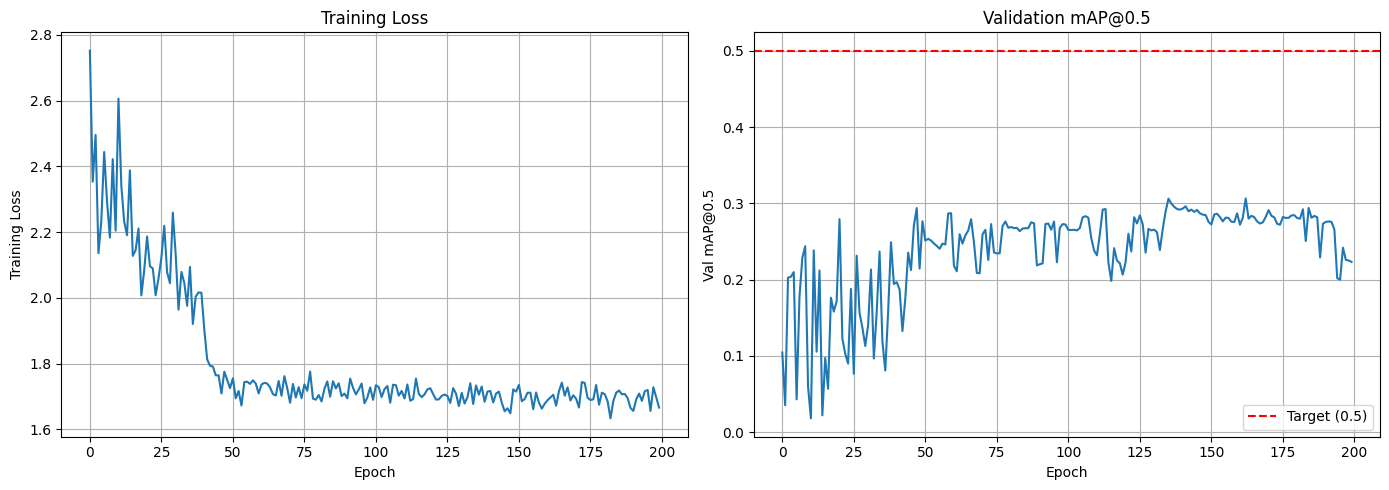

In [44]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'])
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(history['val_map'])
ax2.axhline(y=0.5, color='r', linestyle='--', label='Target (0.5)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Val mAP@0.5')
ax2.set_title('Validation mAP@0.5')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Results Summary

In [52]:
print("\n" + "="*70)
print("EXPERIMENT RESULTS SUMMARY")
print("="*70)
print(f"{'Configuration':<40} | {'Best Val mAP@0.5':>15}")
print("-"*70)
print(f"{'ResNet18, 15 queries (baseline)':<40} | {history['best_map']:>15.4f}")
try:
    print(f"{'MobileNetV2, 15 queries':<40} | {history_mobile['best_map']:>15.4f}")
except:
    pass
try:
    print(f"{'ResNet18, 10 queries':<40} | {history_q10['best_map']:>15.4f}")
    print(f"{'ResNet18, 20 queries':<40} | {history_q20['best_map']:>15.4f}")
except:
    pass
print("="*70)
print(f"\nFinal Test mAP@0.5: {test_map:.4f}")


EXPERIMENT RESULTS SUMMARY
Configuration                            | Best Val mAP@0.5
----------------------------------------------------------------------
ResNet18, 15 queries (baseline)          |          0.3064
MobileNetV2, 15 queries                  |          0.2412
ResNet18, 10 queries                     |          0.2711

Final Test mAP@0.5: 0.2268


## 17. Save Model

In [53]:
torch.save(best_model.state_dict(), 'best_tiny_detr_v3.pth')
print("Model saved to best_tiny_detr_v3.pth")

Model saved to best_tiny_detr_v3.pth
